### Data Cleaning and Preprocessing 
### Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [13]:
# --- 1. Load Data and Initial Cleaning ---
df = pd.read_csv("cardio_train.csv", sep=';')

# Drop 'id' column
df = df.drop('id', axis=1)
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [15]:
# Convert 'age' from days to years
df['age'] = (df['age'] / 365).astype(int)

In [17]:
# --- 2. Handle Missing Values ---
# Check for missing values (Output confirms no missing values)
print("--- Missing Value Check ---")
print(df.isnull().sum())

--- Missing Value Check ---
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [19]:
# Outlier Detection & Removal (BP, Height, Weight) - DO THIS FIRST
df = df[(df['ap_hi'] <= 250) & (df['ap_hi'] >= 70)]
df = df[(df['ap_lo'] <= 200) & (df['ap_lo'] >= 40)]
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

In [78]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_columns = ['height','weight','ap_hi','ap_lo']
df[scaled_columns] = scaler.fit_transform(df[scaled_columns])


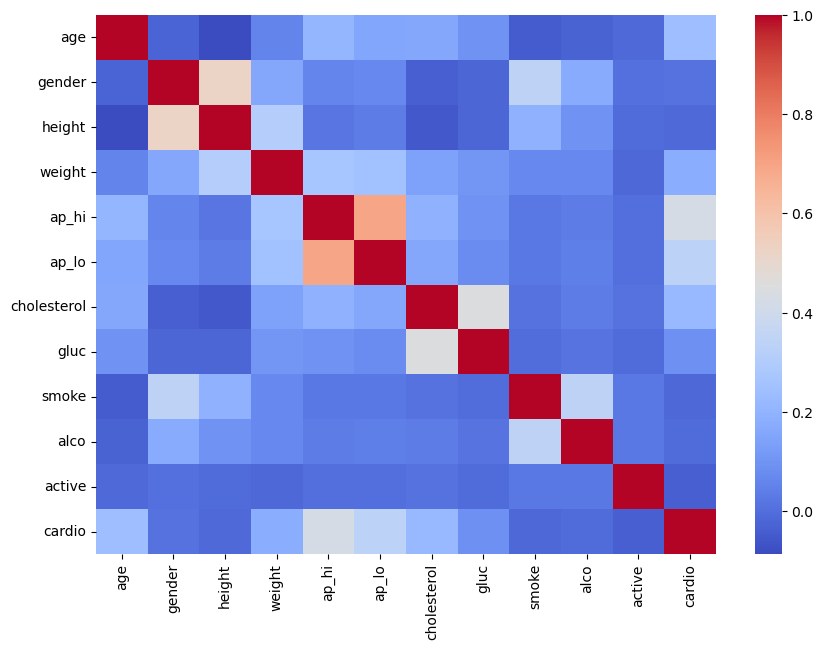

In [21]:
#EDA Visualizations
#1.Correlation Heatmap
%matplotlib inline
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

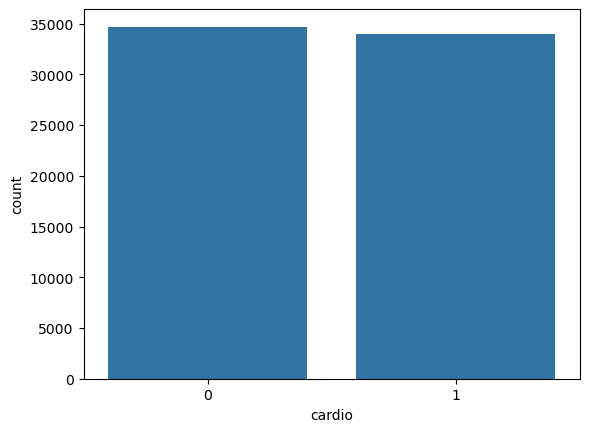

In [23]:
#2.Target Distribution
%matplotlib inline
sns.countplot(x='cardio', data=df)
plt.show()

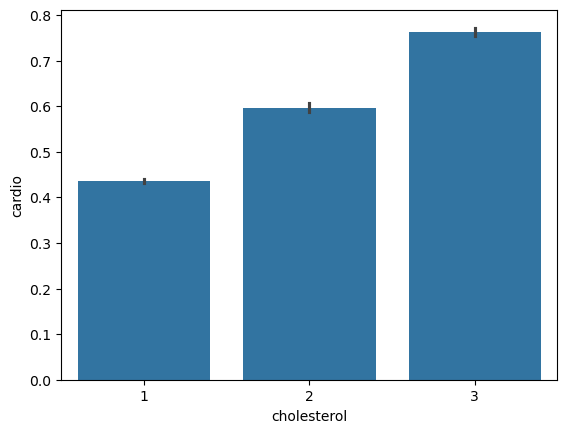

In [25]:
#3.Cholesterol vs Disease
%matplotlib inline
sns.barplot(x='cholesterol', y='cardio', data=df)
plt.show()

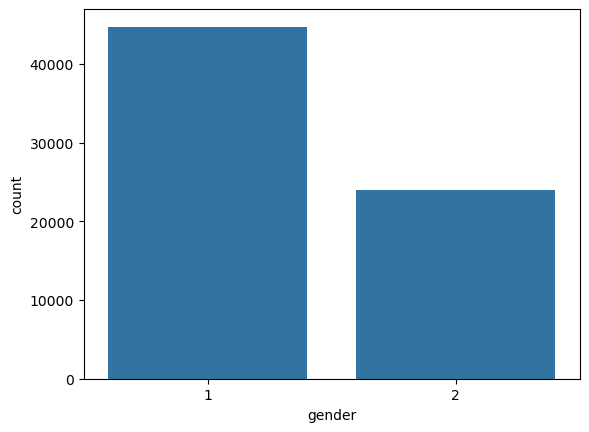

In [27]:
#Gender Count
sns.countplot(x='gender', data=df)
plt.show()


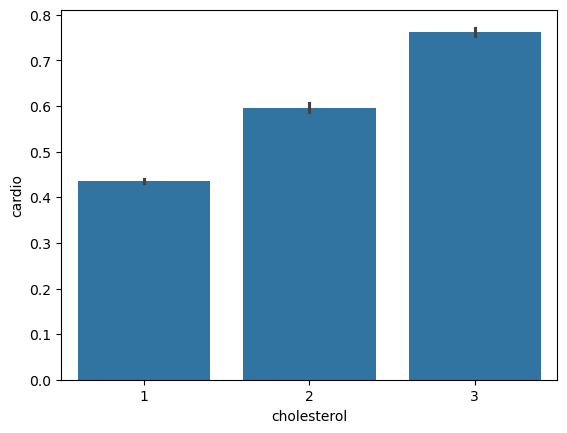

In [29]:
#Cholesterol vs Disease
sns.barplot(x='cholesterol', y='cardio', data=df)
plt.show()


In [31]:
#Show the last 5 rows of the dataframe.
df.tail(5)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,61,1,163,72.0,135,80,1,2,0,0,0,1
69999,56,1,170,72.0,120,80,2,1,0,0,1,0


In [33]:
#Print the number of rows and columns in the dataframe.
df.shape


(68680, 12)

In [35]:
#Find the average age of all people.
df['age'].mean()

52.82986313337216

In [37]:
#Count how many people have heart disease.
df['cardio'].value_counts()

cardio
0    34688
1    33992
Name: count, dtype: int64

In [39]:
#Show the unique cholesterol levels.
df['cholesterol'].unique()


array([1, 3, 2], dtype=int64)

In [41]:
#Show the unique cholesterol levels.
df['height'].unique()


array([168, 156, 165, 169, 151, 157, 178, 158, 164, 173, 181, 172, 170,
       154, 162, 163, 153, 159, 166, 155, 160, 175, 171, 152, 187, 148,
       179, 180, 188, 185, 167, 183, 174, 176, 161, 184, 177, 182, 149,
       142, 150, 144, 147, 186, 146, 141, 195, 140, 198, 145, 143, 196,
       138, 194, 190, 134, 136, 189, 137, 192, 191, 130, 193, 132, 135,
       139, 133, 207, 197, 131], dtype=int64)

In [43]:
#Calculate the average weight grouped by gender.
df.groupby('gender')['weight'].mean()

gender
1    72.472914
2    77.183460
Name: weight, dtype: float64

In [45]:
#Find how many people are physically active.
df['active'].value_counts()

active
1    55181
0    13499
Name: count, dtype: int64

In [47]:
#Find how many people are physically active.
df['height'].value_counts()

height
165    5759
160    4942
170    4606
168    4327
164    3345
       ... 
132       3
134       2
194       2
207       1
131       1
Name: count, Length: 70, dtype: int64

In [49]:
#Convert height from days to years and print first 5.
(df['age'] / 365).head(5)


0    0.136986
1    0.150685
2    0.139726
3    0.131507
4    0.128767
Name: age, dtype: float64

In [51]:
#Find the row with highest cholesterol.
df[df['cholesterol'] == df['cholesterol'].max()]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
6,60,1,157,93.0,130,80,3,1,0,0,1,0
7,61,2,178,95.0,130,90,3,3,0,0,1,1
24,45,1,170,68.0,150,90,3,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
69940,58,1,168,78.0,140,80,3,1,0,0,1,1
69949,60,1,167,68.0,167,85,3,1,0,0,1,1
69956,58,1,158,75.0,120,80,3,3,0,0,1,0
69970,61,2,173,103.0,140,80,3,1,1,1,0,1


In [53]:
#Create a new column BMI = weight / (height/100)^2.
df['BMI'] = df['weight'] / ( (df['height']/100) ** 2 )
df['BMI']

0        21.967120
1        34.927679
2        23.507805
3        28.710479
4        23.011177
           ...    
69995    26.927438
69996    50.472681
69997    31.353579
69998    27.099251
69999    24.913495
Name: BMI, Length: 68680, dtype: float64

In [55]:
#Filter rows where age > 50 years.
df[df['age'] > 50*365]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI


In [57]:
#Sort the dataframe by age in descending order.
df.sort_values(by='age', ascending=False)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
51233,64,1,157,77.0,120,80,2,2,0,0,1,1,31.238590
7064,64,2,165,73.0,140,90,1,1,0,0,1,1,26.813590
7102,64,1,147,61.0,110,70,1,1,0,0,1,0,28.228979
7100,64,1,157,80.0,150,100,3,3,0,0,1,0,32.455678
42042,64,2,162,61.0,130,80,1,1,0,0,1,0,23.243408
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26286,39,1,160,57.0,100,90,1,1,0,0,1,0,22.265625
55905,30,1,160,59.0,110,70,1,1,0,0,1,0,23.046875
6219,29,1,175,59.0,120,80,1,1,0,0,1,0,19.265306
30666,29,1,159,59.0,120,80,1,1,0,0,1,0,23.337684


In [59]:
#Find correlation between height and weight (numeric output only).
df['height'].corr(df['weight'])

0.31114063342371484

### Model Creation 

In [9]:
# Implement selected Algorithm without use of Library.  
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            dw = np.dot(X.T, (y_pred - y)) / len(y)
            db = np.sum(y_pred - y) / len(y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return [1 if i > 0.5 else 0 for i in y_pred]


### Model Evaluation 

In [12]:
def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('cardio_train.csv', sep=';')
df['age'] = (df['age'] / 365.25).astype(int)
df = df[(df['ap_hi'] < 250) & (df['ap_hi'] > 60)]
df = df[(df['ap_lo'] < 200) & (df['ap_lo'] > 40)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# 3. Define Features (X) and Target (y)
X = df.drop(['id', 'cardio'], axis=1).values
y = df['cardio'].values

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the features (This creates X_train_scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled and X_test_scaled are now defined and ready for training.")

X_train_scaled and X_test_scaled are now defined and ready for training.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the library model
lib_model = LogisticRegression()
lib_model.fit(X_train_scaled, y_train)

# Prediction and Accuracy
lib_pred = lib_model.predict(X_test_scaled)
lib_accuracy = accuracy_score(y_test, lib_pred)
print(f"Library Accuracy: {lib_accuracy:.4f}")

Library Accuracy: 0.7258


In [53]:
#Compute metrics and check for overfitting/underfitting.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def perform_task_4(model, X_train, X_test, y_train, y_test):
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # 1. Compute Metrics
    print("--- MODEL EVALUATION ---")
    print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, test_preds))
    
    # 2. Check for Overfitting/Underfitting 
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    
    if train_acc > test_acc + 0.1:
        print("Status: Potential Overfitting detected (High Train Acc, Lower Test Acc).")
    elif train_acc < 0.6:
        print("Status: Potential Underfitting detected (Low Accuracy on both).")
    else:
        print("Status: Model is well-generalized.")

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def perform_task_4(model, X_train, X_test, y_train, y_test):
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    print("\n--- MODEL EVALUATION ---")
    
    # Metrics
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_preds))

    # Overfitting / Underfitting Check
    if train_acc > test_acc + 0.1:
        print("Status: Potential Overfitting detected.")
    elif train_acc < 0.6:
        print("Status: Potential Underfitting detected.")
    else:
        print("Status: Model is well-generalized.")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
